# Canonicalization of Guitar Fretboards from Video Frames
This notebook is a demo of extrscting a canonical, top-down view of a guitar fretboard from raw video frames. This is an improvement on a previous demo that used only a Mask R-CNN seg mask. The original method worked fairly well, but struggled when the mask was noisy or partially occluded by hands.

**Next steps:** switch to YOLO?

In [10]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms as T
from PIL import Image
import cv2
import matplotlib.pyplot as plt

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"using {device}")

using cpu


In [11]:
def get_model_instance_segmentation(num_classes: int = 2):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes,
    )
    return model


def load_fretboard_model(weights_path: str, num_classes: int = 2, device: torch.device = device):
    model = get_model_instance_segmentation(num_classes)
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

In [12]:
transform = T.Compose([T.ToTensor()])

def get_fretboard_mask_from_image(model, img_pil, device=device, confidence_threshold: float = 0.5):
    img_tensor = transform(img_pil).to(device)
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    scores = prediction["scores"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    masks = prediction["masks"].detach().cpu().numpy()  # (N, 1, H, W)

    H, W = img_pil.size[1], img_pil.size[0]
    combined_mask = np.zeros((H, W), dtype=np.uint8)

    for i, score in enumerate(scores):
        if score < confidence_threshold:
            continue
        if labels[i] != 1:
            continue
        m = masks[i, 0]  # (H, W)
        m_bin = (m > 0.5).astype(np.uint8)
        combined_mask = np.logical_or(combined_mask, m_bin).astype(np.uint8)

    combined_mask = (combined_mask * 255).astype(np.uint8)
    return combined_mask

In [4]:
def clean_mask(mask: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    if mask.max() == 1:
        mask = (mask * 255).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask_opened = cv2.morphologyEx(mask_closed, cv2.MORPH_OPEN, kernel)

    # Connected components to keep largest region only
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask_opened > 0).astype(np.uint8), connectivity=8)
    if num_labels <= 1:
        return (mask_opened > 0).astype(np.uint8) * 255

    # Skip background (label 0), find largest area
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + np.argmax(areas)
    cleaned = (labels == largest_label).astype(np.uint8) * 255
    return cleaned


def get_contour_and_min_area_rect(mask: np.ndarray):
    contours, _ = cv2.findContours((mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)  # 4x2 float
    box = np.array(box, dtype=np.float32)
    return contour, box


def order_corners_tl_tr_bl_br(box: np.ndarray) -> np.ndarray:
    assert box.shape == (4, 2)
    # Based on sums and differences
    s = box.sum(axis=1)
    diff = np.diff(box, axis=1)[:, 0]

    tl = box[np.argmin(s)]
    br = box[np.argmax(s)]
    tr = box[np.argmin(diff)]
    bl = box[np.argmax(diff)]

    return np.array([tl, tr, bl, br], dtype=np.float32)

In [13]:
def compute_homography_and_warp(image_bgr: np.ndarray,
                                src_corners: np.ndarray,
                                out_width: int = 1024,
                                out_height: int = 256) -> (np.ndarray, np.ndarray):
    assert src_corners.shape == (4, 2)

    dst_corners = np.array([
        [0, 0],
        [out_width - 1, 0],
        [0, out_height - 1],
        [out_width - 1, out_height - 1],
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(src_corners.astype(np.float32), dst_corners)
    warped = cv2.warpPerspective(image_bgr, H, (out_width, out_height))
    return warped, H

In [14]:
# === User configuration ===
MODEL_WEIGHTS_PATH = "model_weights.pt"
IMAGE_PATH = "guitar_test_clean.png"
CONFIDENCE_THRESHOLD = 0.5
OUT_WIDTH, OUT_HEIGHT = 1024, 256

assert os.path.exists(MODEL_WEIGHTS_PATH), f"Weights not found: {MODEL_WEIGHTS_PATH}"
assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"

model = load_fretboard_model(MODEL_WEIGHTS_PATH, num_classes=2, device=device)
print("Model loaded :)")

Model loaded :)


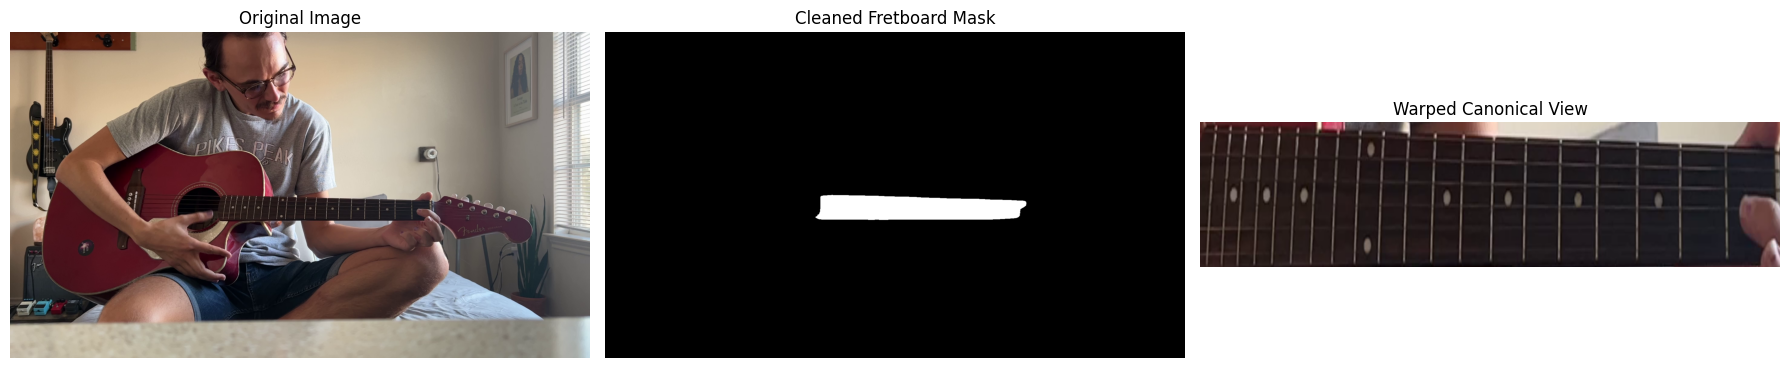

In [15]:
def run_full_pipeline(image_path: str):

    img_pil = Image.open(image_path).convert("RGB")
    img_np = np.array(img_pil)[:, :, ::-1]

    # 1) segmentation to binary mask
    raw_mask = get_fretboard_mask_from_image(model, img_pil, device=device, confidence_threshold=CONFIDENCE_THRESHOLD)

    # 2) cleaning mask
    cleaned_mask = clean_mask(raw_mask, kernel_size=5)

    # 3) contour + min-area rectangle
    contour, box = get_contour_and_min_area_rect(cleaned_mask)
    if contour is None or box is None:
        print("no fretboard contour found")
        return

    src_corners = order_corners_tl_tr_bl_br(box)

    # 4) computing homography and warping
    warped_bgr, H = compute_homography_and_warp(img_np, src_corners,
                                                out_width=OUT_WIDTH,
                                                out_height=OUT_HEIGHT)

    # visualization
    vis_bgr = img_np.copy()
    cv2.drawContours(vis_bgr, [contour], -1, (0, 255, 0), 2)
    cv2.polylines(vis_bgr, [src_corners.astype(np.int32)], isClosed=True, color=(0, 0, 255), thickness=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cleaned_mask, cmap="gray")
    axes[1].set_title("Cleaned Fretboard Mask")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Warped Canonical View")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "homography": H,
        "src_corners": src_corners,
        "warped": warped_bgr,
        "mask": cleaned_mask,
    }


results = run_full_pipeline(IMAGE_PATH)